# Grundläggande analys och statistik

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy import stats
from statsmodels.stats.power import TTestIndPower

In [2]:
class HealthAnalyzer:

    # Loading and summerizing

    def __init__(self, csv_path: str):
        """
        Loading the .csv file into a DataFrame from given path.
        """
        self.df: pd.DataFrame = pd.read_csv(csv_path)
    
    def describe(self):
        """
        Display statistics rounded by 2 decimals.
        """
        display(self.df.describe().round(2))

    def info(self):
        """
        Display info about the data: columns, missing values, Dtype
        """
        self.df.info()
    
    def summary(self):
        """
        Displays a summary of mean, median, min and max for: age, weight, systolic blood pressure, cholesterol.
        """
        data_summary =  (self.df[["age", "weight", "height", "systolic_bp", "cholesterol"]]
                 .agg(["mean", "median", "min", "max"])
                 .round(2)
                 )
        display(data_summary)

    # Visualizations

    def weight_per_sex_viz(self):
        """
        Displays a boxplot of weight per sex
        """
        fig, ax = plt.subplots(figsize=(8,5))
        ax.boxplot([self.df.loc[self.df["sex"] == "M", "weight"], 
            self.df.loc[self.df["sex"] == "F", "weight"]], 
            tick_labels=["Male", "Female"]
            )
        ax.set_xlabel("Sex")
        ax.set_ylabel("Weight")
        ax.set_title("Weight per sex")
        plt.tight_layout()
        plt.show()
    
    def bp_amount_viz(self, bins: int= 25):
        """
        Displays a histogram of amount of people by blood pressure, number of bins by default is 25.\n
        bins : number of bins, 25 by default.
        """
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.hist(self.df["systolic_bp"].dropna(), bins = bins, edgecolor="black")
        ax.set_title("Amount of people with a certain blood pressure")
        ax.set_xlabel("Blood pressure")
        ax.set_ylabel("Amount of people")
        ax.grid(True, axis="y")
        plt.tight_layout()
        plt.show()
    
    def bp_by_smoker_viz(self):
        """
        Displays a violin plot of systolic blood pressure by smokers/non-smokers.
        """
        fig, ax = plt.subplots(figsize=(8,5))
        ax.violinplot([self.df.loc[self.df["smoker"] == "Yes", "systolic_bp"], 
               self.df.loc[self.df["smoker"] == "No", "systolic_bp"]], 
               showmeans=True, showmedians=True
               )
        ax.set_title("Violin plot of systolic blood pressure by smoker/non-smoker")
        ax.set_xlabel("Group")
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Smoker", "Non-smoker"])
        ax.set_ylabel("Blood pressure")
        ax.grid(True, axis="y", alpha=0.5)
        plt.tight_layout()
        plt.show()
    
    # Compare

    def compare_disease(self, n = 1000):
        """
        Displays observed % of people with the disease, and compares it to a randomized simulation using the same % as observed.\n
        n : size of simulated population, 1000 by default.
        """
        
        disease_amount = self.df["disease"].mean()
        np.random.seed(42)

        disease_simulated = np.random.choice([1, 0], p=[disease_amount, 1-disease_amount], size=n)
        disease_simulated_percentage = disease_simulated.mean()

        print(f"{disease_amount*100:.3f}% of the people in the health study has the disease.")
        print(f"Randomized number of disease per {n} people with the same percentage as observed({disease_amount*100:.3f}%) gives {disease_simulated_percentage*100:.3f}%.")

        # Compare results.
        if disease_simulated_percentage > disease_amount:
            print(f"Simulated percentage is {(disease_simulated_percentage - disease_amount)*100:.3f}% larger than observed.")
        elif disease_simulated_percentage < disease_amount:
            print(f"Simulated percentage is {abs(disease_simulated_percentage - disease_amount)*100:.3f}% smaller than observed.")
        else:
            print("There is no difference between the simulated and observed percentage.")

    # Statistical tests.

    def welch_t_test(self):
        """
        Calculates and displays the p-value and t-stat of the data to see if the average value of blood pressure between smokers and non-smokers truly differ.
        """
        smokers_bp = self.df[self.df["smoker"] == "Yes"]["systolic_bp"]
        nonsmokers_bp = self.df[self.df["smoker"] == "No"]["systolic_bp"]

        t_stat, p_val = stats.ttest_ind(smokers_bp, nonsmokers_bp, equal_var=False)

        print(f"Mean for smokers: {smokers_bp.mean():.3f}")
        print(f"Mean for non-smokers: {nonsmokers_bp.mean():.3f}")
        print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.3f}")
    
    def normal_approx_method(self):
        """
        Confidence interval using the normal approximation method, displays mean, standard deviation, standard error and 95% CI.
        """
        # Confidence interval using the normal approximation method.
        n = len(self.df["systolic_bp"])
        s = self.df["systolic_bp"].std(ddof=1)
        mean_x = self.df["systolic_bp"].mean()
        z = 1.96
        se = s / np.sqrt(n)

        low = mean_x - z * se
        high = mean_x + z * se

        print(f"Mean: {mean_x:.2f}")
        print(f"Standard deviation: {s:.2f}")
        print(f"Standard error: {se:.2f}\n")
        print(f"Normal approximation 95% CI: {low:.2f}, {high:.2f}")

    def bootstrap_method(self, B: int= 10000, confidence: float= 0.95):
        """
        Bootstrap method for confidence interval for mean systolic blood pressure, 95% by default. Compares results with normal approximation method.\n
        B : Number of resamples (10 000 by default)
        confidence : 95% by default
        """
        z = 1.96
        np.random.seed(42)
        boot_x = self.df["systolic_bp"]
        boot_n = len(boot_x)
        boot_means = np.empty(B)
        mean_x = self.df["systolic_bp"].mean()

        s = self.df["systolic_bp"].std(ddof=1)
        n = len(self.df["systolic_bp"])
        se = s / np.sqrt(n)

        low = mean_x - z * se
        high = mean_x + z * se

        for b in range(B):
            boot_sample = np.random.choice(boot_x, size=boot_n, replace=True)
            boot_means[b] = np.mean(boot_sample)

        alpha = (1 - confidence) / 2
        boot_lo, boot_hi = np.percentile(boot_means, [100*alpha, 100*(1-alpha)])

        print(f"Bootstrap 95% CI: {boot_lo:.2f}, {boot_hi:.2f}")
        print(f"\nDifference in CI between the two methods: lower={(boot_lo - low):.3f}, upper = {(boot_hi - high):.3f}\n")

    def power_t_test(self, alpha: float=0.05, power: float=0.8):
        """
        Tests the power of our t-test by calculating the statistical power and size needed to achieve 80%(default) power.\n
        alpha : 5% default, acceptable risk of false-positive
        power : 80% by default, needed for test to detect any statistically significant effects.
        """
        smokers_bp = self.df[self.df["smoker"] == "Yes"]["systolic_bp"]
        nonsmokers_bp = self.df[self.df["smoker"] == "No"]["systolic_bp"]
        mean_smokers = smokers_bp.mean()
        mean_non = nonsmokers_bp.mean()
        n_smokers = len(smokers_bp)
        n_non = len(nonsmokers_bp)

        sd_pooled = np.sqrt(((n_smokers -1) * smokers_bp.std(ddof=1) ** 2 + (n_non - 1)*nonsmokers_bp.std(ddof=1)**2) / (n_smokers + n_non -2))

        cohen_d = (mean_smokers - mean_non) / sd_pooled

        ratio = n_smokers / n_non

        power_T = TTestIndPower().power(
            effect_size=cohen_d,
            nobs1=n_non,
            alpha=alpha,
            ratio=ratio,
            alternative="larger"
        )

        n_needed_T = TTestIndPower().solve_power(
            effect_size=cohen_d,
            alpha=alpha,
            power=power,
            ratio=ratio,
            alternative="larger"
        )

        print(f"Power for the test to detect a difference: {power_T*100:.2f}%")
        print(f"Sample size needed to reach a power of {power*100:.2f}%: {n_needed_T:.0f} -- compared to the observed sample size of {len(self.df["smoker"])} people.")

data_set = HealthAnalyzer("data/health_study_dataset.csv")


In [3]:
data_set.describe()
data_set.info()

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,49.43,171.85,73.41,149.18,4.93,0.06
std,231.08,14.50,9.80,13.69,12.79,0.85,0.24
min,1.00,18.00,144.40,33.70,106.80,2.50,0.00
25%,200.75,39.00,164.78,64.80,140.90,4.33,0.00
50%,400.50,50.00,171.35,73.20,149.40,4.97,0.00
75%,600.25,59.00,178.92,82.60,157.60,5.48,0.00
max,800.00,90.00,200.40,114.40,185.90,7.88,1.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


**Mean, median, min och max for: age, weight, height, systolic blood pressure, cholesterol**

In [4]:
data_set.summary()

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


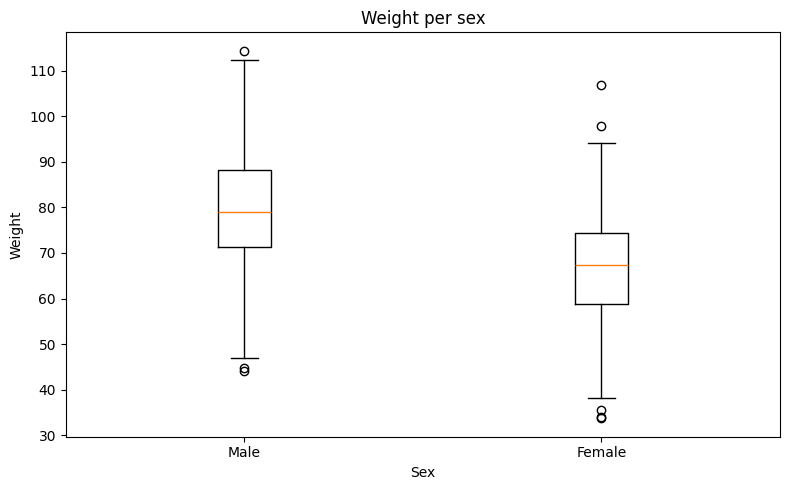

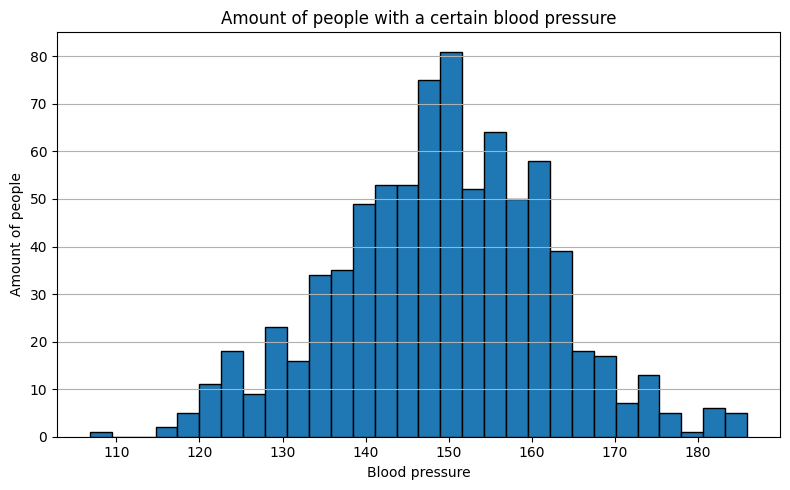

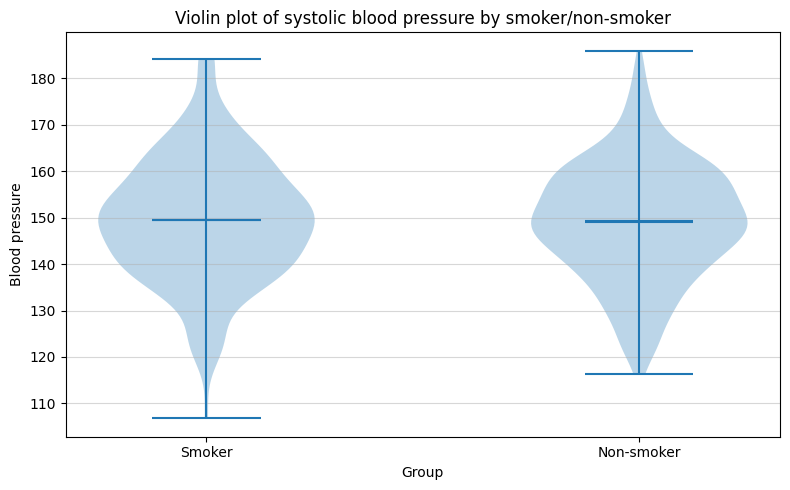

In [5]:
data_set.weight_per_sex_viz()
data_set.bp_amount_viz(bins = 30)
data_set.bp_by_smoker_viz()

In [6]:
data_set.compare_disease(n = 2000)

5.875% of the people in the health study has the disease.
Randomized number of disease per 2000 people with the same percentage as observed(5.875%) gives 6.050%.
Simulated percentage is 0.175% larger than observed.


**Confidence interval of mean of systolic blood pressure.**

In [7]:
data_set.normal_approx_method()
data_set.bootstrap_method()

Mean: 149.18
Standard deviation: 12.79
Standard error: 0.45

Normal approximation 95% CI: 148.29, 150.07
Bootstrap 95% CI: 148.30, 150.07

Difference in CI between the two methods: lower=0.005, upper = 0.008



Comparing these two methods, normal approximation and bootstrap, shows similar results regarding CI-values. This tells us that normal approximation is sufficient for this study. Bootstrap is generally more reliable with smaller samples and does not rely on assumptions about the data, it can improve accuracy through resampling. However, seeing the results are almost identical, they both produce values that are reliable for this study, but using both strengthens the result.

External source: https://www.geeksforgeeks.org/maths/bootstrap-method/

**Hypothesis test: smokers have higher mean blood pressure than non-smokers.**

For the test I've chosen to use a Welch t-test. The reasons being that we compare two groups of unequal sample size, but with sufficiently large sample sizes to not need a bootstrap test. 

In [8]:
data_set.welch_t_test()

Mean for smokers: 149.525
Mean for non-smokers: 149.053
Standard t-test: t = 0.450, p = 0.653


A welch t-test value of 0.45 is a value close to 0, which indicates there's no reliable statistical difference between the groups. Paired with a large p-value of 0.645, which means 65.3% of the time a random sample would produce a difference this big or bigger if there were no differences between groups. The welch t-test shows no statistically significant difference between smokers and non-smokers when it comes to systolic blood pressure.

External source: https://www.geeksforgeeks.org/r-language/running-two-sample-t-test-with-unequal-sample-size-in-r/

**Testing the power of my t-test.**

In [9]:
data_set.power_t_test()

Power for the test to detect a difference: 11.81%
Sample size needed to reach a power of 80.00%: 17084 -- compared to the observed sample size of 800 people.


Based on these results, the chance to detect a real difference is very low with the sample size we have. We would need a much larger sample size to be able to achieve the statistical power of 80% and be able to apply any statistical certainty to our results. With this data and all results in mind(normal aprox, bootstrap, welch t-test and power), there is no support for there being a significant difference between smokers and non-smokers regarding their systolic blood pressure.


Alexander Ahl